In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import RobustScaler, LabelEncoder

In [116]:
df = pd.read_csv("laptop_price.csv", encoding="unicode_escape")
df.head(8)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
5,6,Acer,Aspire 3,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,400.00
6,7,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,2139.97
7,8,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,1158.70


In [117]:
df.shape

(1303, 13)

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [119]:
cat_cols = ['Company', 'TypeName', 'Ram', 'OpSys']
num_cols = ['laptop_ID', 'Inches', 'Price_euros']
cat_but_car = ['Product', 'ScreenResolution', 'Cpu', 'Memory', 'Gpu', 'Weight']

In [120]:
def plot_categorical(dataframe, categorical_columns):
    num_cols = len(categorical_columns)
    num_rows = num_cols
    fig, axes = plt.subplots(num_rows, 2, figsize=(20, 5 * num_rows))
    axes = axes.flatten()

    for i, col in enumerate(categorical_columns):
        # Countplot
        sns.countplot(x=col, data=dataframe, ax=axes[2*i])
        axes[2*i].set_title(f'{col} Count')
        axes[2*i].set_xlabel(col)
        axes[2*i].set_ylabel('Count')

        # Pieplot
        dataframe[col].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[2*i+1])
        axes[2*i+1].set_title(f'{col} Distribution')
        axes[2*i+1].set_ylabel('')

    plt.tight_layout()
    plt.show()

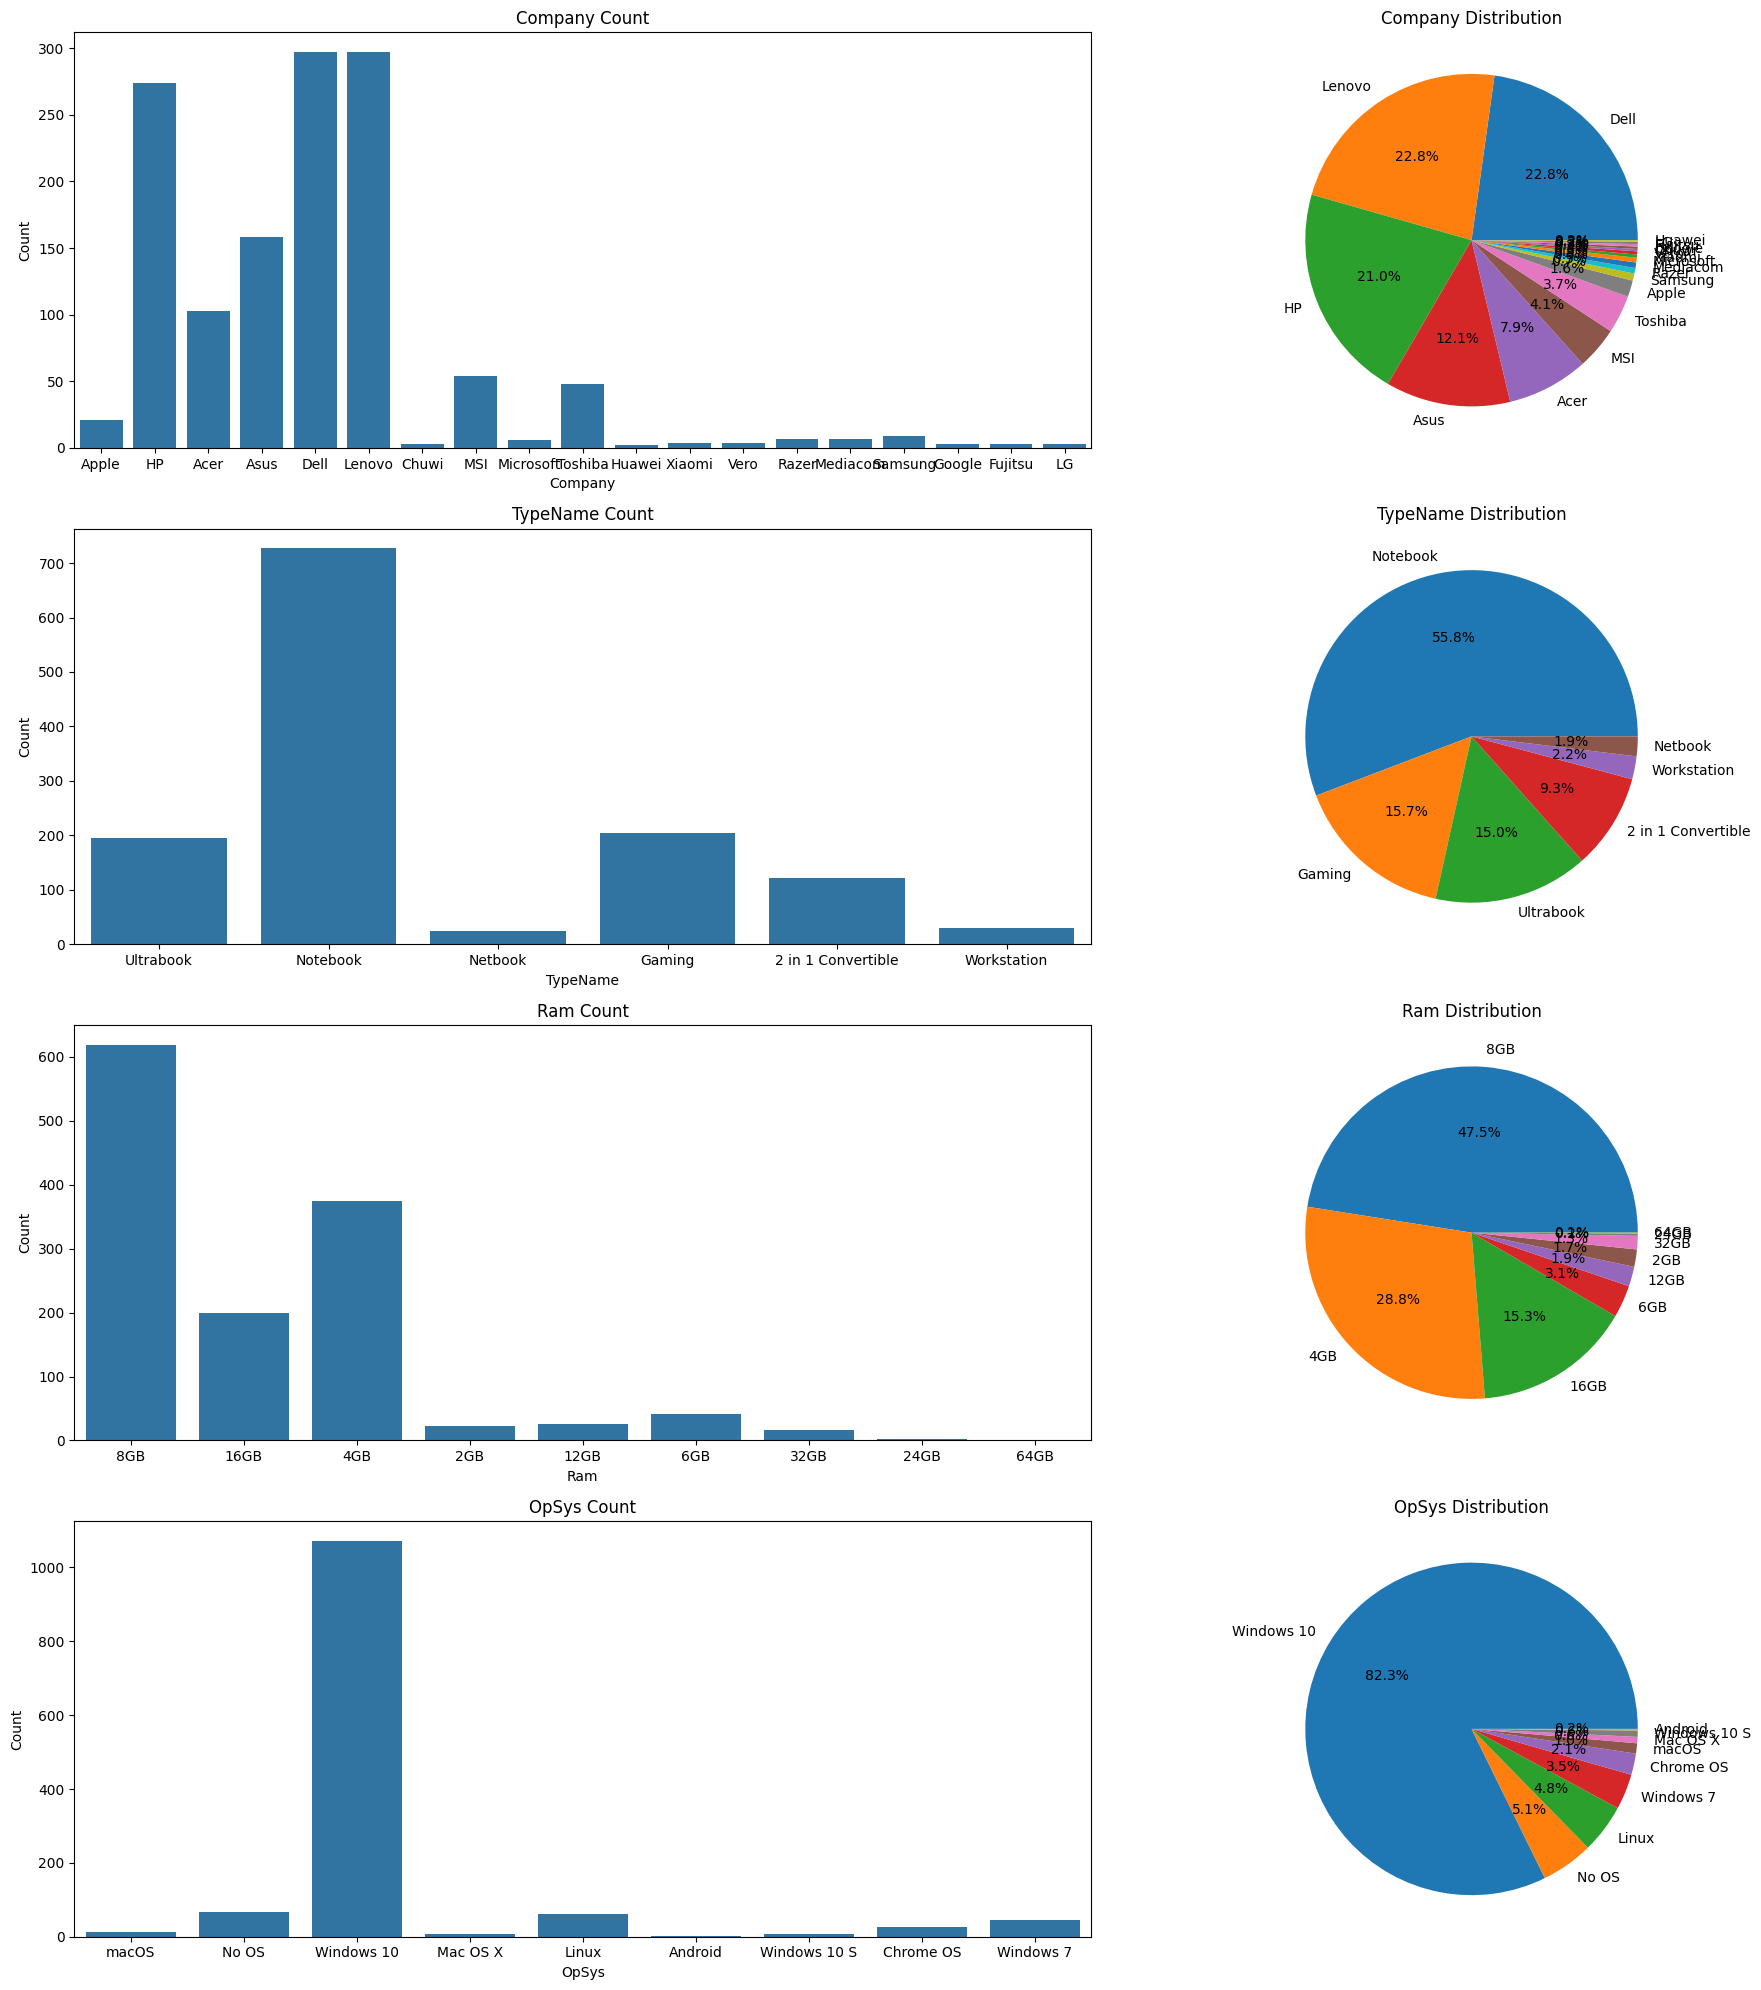

In [121]:
plot_categorical(df, cat_cols)

In [122]:
df.columns

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='object')

In [123]:
df.drop("laptop_ID",axis=1, inplace=True)
df.drop("Product", axis = 1, inplace=True)
df["Weight"] = df["Weight"].str.replace("kg","").astype(float)
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60
...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,638.00
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,1499.00
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,229.00
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,764.00


In [124]:
df = pd.get_dummies(data=df, columns = ["Company"], drop_first=True)

# Prepare dataset

In [140]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols = ['TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu',
       'OpSys']
for col in cols:
    df[col] = le.fit_transform(df[col])
df.head()

,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,...,Company_LG,Company_Lenovo,Company_MSI,Company_Mediacom,Company_Microsoft,Company_Razer,Company_Samsung,Company_Toshiba,Company_Vero,Company_Xiaomi
0,4,13.3,23,65,8,4,58,8,1.37,1339.69,...,False,False,False,False,False,False,False,False,False,False
1,4,13.3,1,63,8,2,51,8,1.34,898.94,...,False,False,False,False,False,False,False,False,False,False
2,3,15.6,8,74,8,16,53,4,1.86,575.00,...,False,False,False,False,False,False,False,False,False,False
3,4,15.4,25,85,1,29,9,8,1.83,2537.45,...,False,False,False,False,False,False,False,False,False,False
4,4,13.3,23,67,8,16,59,8,1.37,1803.60,...,False,False,False,False,False,False,False,False,False,False


In [141]:
X = df.drop("Price_euros", axis = 1)
y = df["Price_euros"]

In [142]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=11)

In [128]:
import tensorflow as tf

# Tensorflow

In [143]:
X = tf.constant(df.loc[:, df.columns != 'Price_euros'], dtype = tf.float32, name = "features")
y = tf.constant(df["Price_euros"], dtype = tf.float32, name = "target")

In [144]:
n_epoch = 10000
learning_rate = 0.000001
m, n = df.shape
n = n-1

In [145]:
theta = tf.Variable(tf.random.uniform([n, 1], -1.0, 1.0), name = "theta")
theta

<tf.Variable 'theta:0' shape=(27, 1) dtype=float32, numpy=
array([[-0.59669733],
       [ 0.41183305],
       [ 0.8747802 ],
       [-0.13340902],
       [-0.89133024],
       [-0.72259974],
       [ 0.1573143 ],
       [ 0.9686153 ],
       [ 0.12716126],
       [ 0.99148536],
       [-0.7740512 ],
       [ 0.46213627],
       [-0.48395586],
       [ 0.7769985 ],
       [-0.00183082],
       [-0.8133235 ],
       [ 0.00205493],
       [ 0.35106826],
       [-0.64672613],
       [-0.05997372],
       [ 0.58523655],
       [ 0.18536401],
       [-0.03756309],
       [ 0.2695198 ],
       [-0.58994675],
       [-0.322083  ],
       [-0.19961214]], dtype=float32)>

In [149]:
# Fit model

for epoch in range(n_epoch):
   y_pred = tf.matmul(X, theta, name = "predictions")
   error = y_pred - y
   mse = tf.reduce_mean(tf.square(error), name = "mse")
   gradients = 2/m * tf.matmul(tf.transpose(X), error)
   theta = theta - learning_rate * gradients

   if epoch % 100 == 0:
      print("Epoch: ", epoch, "MSE: ", mse)

Epoch:  0 MSE:  tf.Tensor(1754319.9, shape=(), dtype=float32)
Epoch:  100 MSE:  tf.Tensor(158032.08, shape=(), dtype=float32)
Epoch:  200 MSE:  tf.Tensor(131486.06, shape=(), dtype=float32)
Epoch:  300 MSE:  tf.Tensor(128920.766, shape=(), dtype=float32)
Epoch:  400 MSE:  tf.Tensor(126782.5, shape=(), dtype=float32)
Epoch:  500 MSE:  tf.Tensor(124710.26, shape=(), dtype=float32)
Epoch:  600 MSE:  tf.Tensor(122696.44, shape=(), dtype=float32)
Epoch:  700 MSE:  tf.Tensor(120738.92, shape=(), dtype=float32)
Epoch:  800 MSE:  tf.Tensor(118835.77, shape=(), dtype=float32)
Epoch:  900 MSE:  tf.Tensor(116985.09, shape=(), dtype=float32)
Epoch:  1000 MSE:  tf.Tensor(115185.1, shape=(), dtype=float32)
Epoch:  1100 MSE:  tf.Tensor(113434.05, shape=(), dtype=float32)
Epoch:  1200 MSE:  tf.Tensor(111730.26, shape=(), dtype=float32)
Epoch:  1300 MSE:  tf.Tensor(110072.125, shape=(), dtype=float32)
Epoch:  1400 MSE:  tf.Tensor(108458.086, shape=(), dtype=float32)
Epoch:  1500 MSE:  tf.Tensor(106886.

In [158]:
X_train_tensor = tf.convert_to_tensor(X_train.values, dtype=tf.float32)
y_train_tensor = tf.convert_to_tensor(y_train.values, dtype=tf.float32)

num_features = X_train_tensor.shape[1]


w = tf.Variable(tf.random.normal([num_features, 1]))
b = tf.Variable(tf.zeros([1]))


X_test_tensor = tf.convert_to_tensor(X_test.values, dtype=tf.float32)
y_test_tensor = tf.convert_to_tensor(y_test.values, dtype=tf.float32)


In [151]:
y_pred_tensor = tf.matmul(X_test_tensor, w) + b
test_loss = tf.reduce_mean((y_test_tensor - y_pred_tensor) ** 2)

print(f"Test Loss: {test_loss.numpy()}")

Test Loss: 1662505.875


# Pytorch

In [165]:
import torch

In [166]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

# y_pred_tensor = torch.matmul(X_test_tensor, w) + b
# test_loss = torch.mean((y_test_tensor - y_pred_tensor) ** 2)

# print(f"Test Loss: {test_loss.item()}")
# X_train.info()


TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.